In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.ticker as mticker

from pathlib import Path
from matplotlib.ticker import MaxNLocator
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.stattools import acf, pacf, ccf, adfuller, coint
from statsmodels.tsa.stattools import ccf as ccf_func
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf,  plot_ccf
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# 输出文件夹
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1.数据预处理

In [3]:
# 1.1 读取数据
df_raw = pd.read_csv("sg_temperature_rainfall.csv", skiprows=9)

df_raw = df_raw.set_index('Data Series')
data = df_raw.T.reset_index()

data = data.rename(columns={
    'index': 'Year',
    'Air Temperature Means Daily Minimum (Degree Celsius)': 'Temp_Min',
    'Total Rainfall (Millimetre)': 'Rainfall'
})
data = data[['Year', 'Temp_Min', 'Rainfall']].copy()

data['Year'] = pd.to_numeric(data['Year'], errors='coerce')
data['Temp_Min'] = pd.to_numeric(data['Temp_Min'], errors='coerce')
data['Rainfall'] = pd.to_numeric(data['Rainfall'], errors='coerce')

data = data.dropna(subset=['Year']) 
data['Year'] = data['Year'].astype(int) 
data = data.sort_values('Year').set_index('Year')

print(f"数据大小：{data.shape[0]} 行 × {data.shape[1]} 列")
print("数据预览：")
print(data.head())

数据大小：65 行 × 2 列
数据预览：
Data Series  Temp_Min  Rainfall
Year                           
1960             23.7    1569.6
1961             23.6    1817.6
1962             23.5    2293.2
1963             23.5    1824.1
1964             23.4    2833.2


In [4]:
# 1.2 检查各列的缺失值数量
missing_info = data.isnull().sum()
print("--- 缺失值检查报告 ---")
print(missing_info[missing_info > 0] if missing_info.sum() > 0 else "所有列均无缺失值!")

year_diff = np.diff(data.index)
if any(year_diff > 1):
    missing_years = []
    for i in range(len(data.index) - 1):
        if data.index[i+1] - data.index[i] > 1:
            missing_years.extend(range(data.index[i]+1, data.index[i+1]))
    print(f"注意：年份索引不连续！缺失的年份有: {missing_years}")
else:
    print("年份索引连续，无需插值处理!")


--- 缺失值检查报告 ---
所有列均无缺失值!
年份索引连续，无需插值处理!


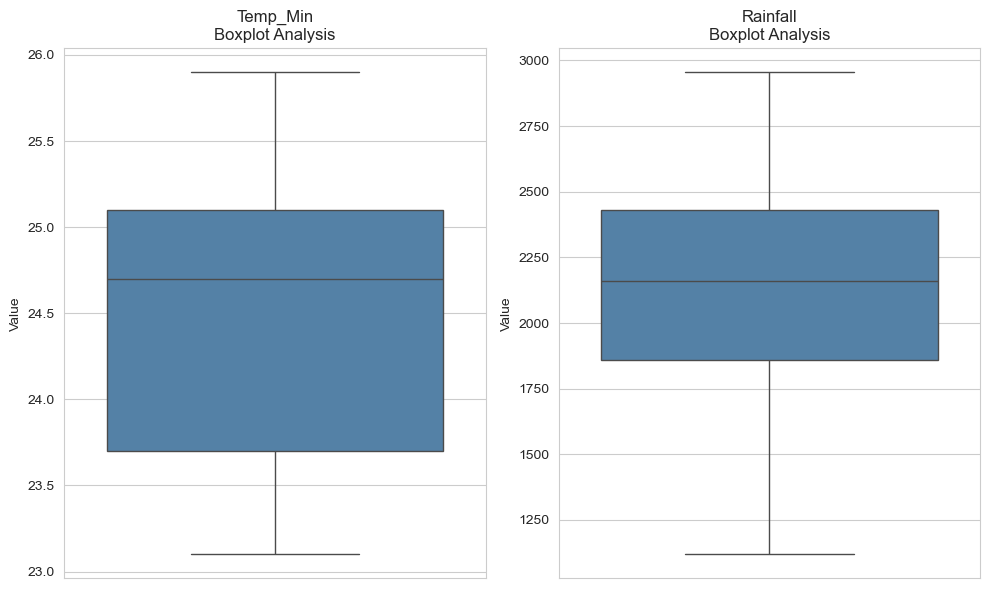

In [5]:
# 1.3 异常值检测
def plot_outliers_boxplot(data, columns):
   
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    for i, col in enumerate(columns, 1):
        plt.subplot(1, len(columns), i)
        
        sns.boxplot(y=data[col], color='steelblue', 
                    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})
        
        plt.title(f'{col}\nBoxplot Analysis')
        plt.ylabel('Value')
        
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'Outlier_Boxplot.png')
    plt.show()

plot_outliers_boxplot(data, ['Temp_Min', 'Rainfall'])

## 2.时间序列描述性统计与图形化探索

In [6]:
# 2.1 基本统计量
ts = data['Temp_Min']

print(ts.describe())

print("\n--- 核心统计指标 (核心分析用) ---")
print(f"均值 (Mean)   : {ts.mean():>15.4f}") 
print(f"方差 (Var)    : {ts.var():>15.4f}")  
print(f"标准差 (Std)  : {ts.std():>15.4f}")  
print(f"偏度 (Skew)   : {ts.skew():>15.4f}")  
print(f"峰度 (Kurt)   : {ts.kurt():>15.4f}")  

count    65.000000
mean     24.487692
std       0.783723
min      23.100000
25%      23.700000
50%      24.700000
75%      25.100000
max      25.900000
Name: Temp_Min, dtype: float64

--- 核心统计指标 (核心分析用) ---
均值 (Mean)   :         24.4877
方差 (Var)    :          0.6142
标准差 (Std)  :          0.7837
偏度 (Skew)   :         -0.1223
峰度 (Kurt)   :         -1.0666


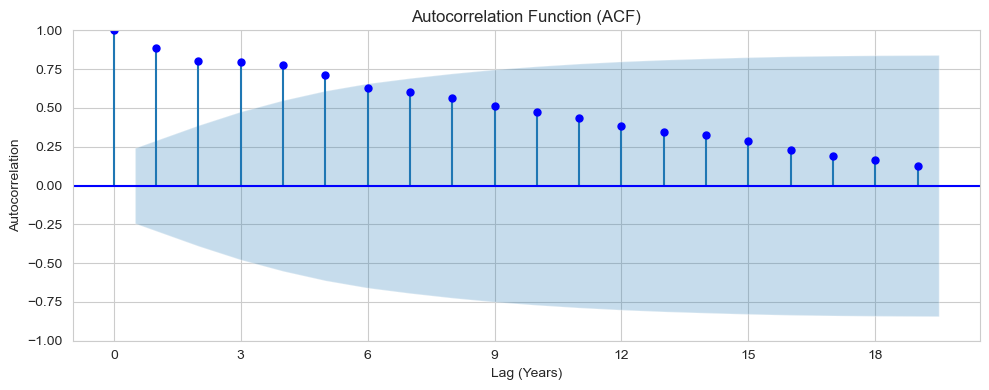

In [7]:
# 2.2 绘制 ACF 图
fig, ax = plt.subplots(figsize=(10, 4))

plot_acf(data['Temp_Min'], ax=ax, color='blue')

ax.set_title('Autocorrelation Function (ACF)')
ax.set_xlabel('Lag (Years)')
ax.set_ylabel('Autocorrelation')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'TempMin_ACF_Diagnosis.png')
plt.show()

In [8]:
# 2.3 ADF平稳性检验
adf_result = adfuller(data['Temp_Min'], autolag='AIC')

print(f'ADF 统计量：{adf_result[0]:.4f}')
print(f'p 值：      {adf_result[1]:.4f}')
print(f'使用滞后数：{adf_result[2]}')
print('临界值：')
for k, v in adf_result[4].items():
    print(f'  {k}: {v:.4f}')

if adf_result[1] < 0.05:
    print('\n结论：p < 0.05，序列平稳，无需差分。')
else:
    print('\n结论：p >= 0.05，序列不平稳，需要差分（d >= 1）。')

ADF 统计量：-0.4683
p 值：      0.8980
使用滞后数：3
临界值：
  1%: -3.5424
  5%: -2.9102
  10%: -2.5927

结论：p >= 0.05，序列不平稳，需要差分（d >= 1）。


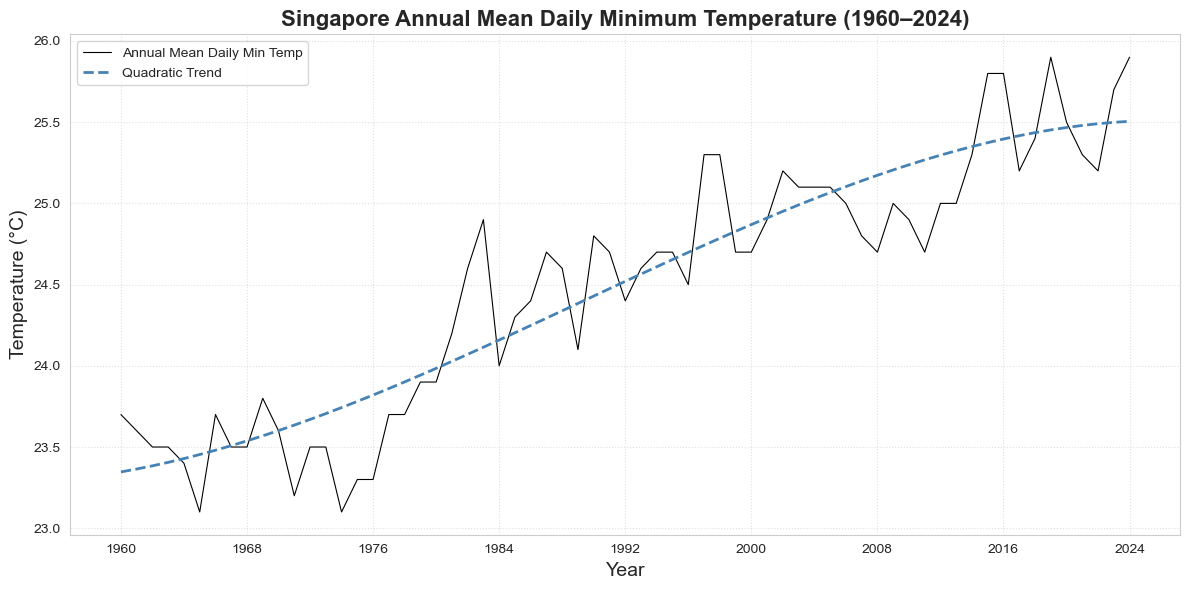

In [9]:
# 2.4 绘制折线图
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot( data['Temp_Min'].index, data['Temp_Min'].values, color='black', linewidth=0.8, label='Annual Mean Daily Min Temp')
x_num = np.arange(len( data['Temp_Min']))
z = np.polyfit(x_num,  data['Temp_Min'].values,3) 
p = np.poly1d(z)

ax.plot(data['Temp_Min'].index, p(x_num), color='steelblue', linewidth=2, linestyle='--', label='Quadratic Trend')

ax.set_title('Singapore Annual Mean Daily Minimum Temperature (1960–2024)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Temperature (°C)', fontsize=14)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'TempMin_(1960-2024).png')
plt.show()

## 3. 简单指数平滑模型

=== SES 模型参数 (自动优化) ===
自动搜索到的最优 Alpha: 0.5197
初始水平 Initial Level: 23.7000



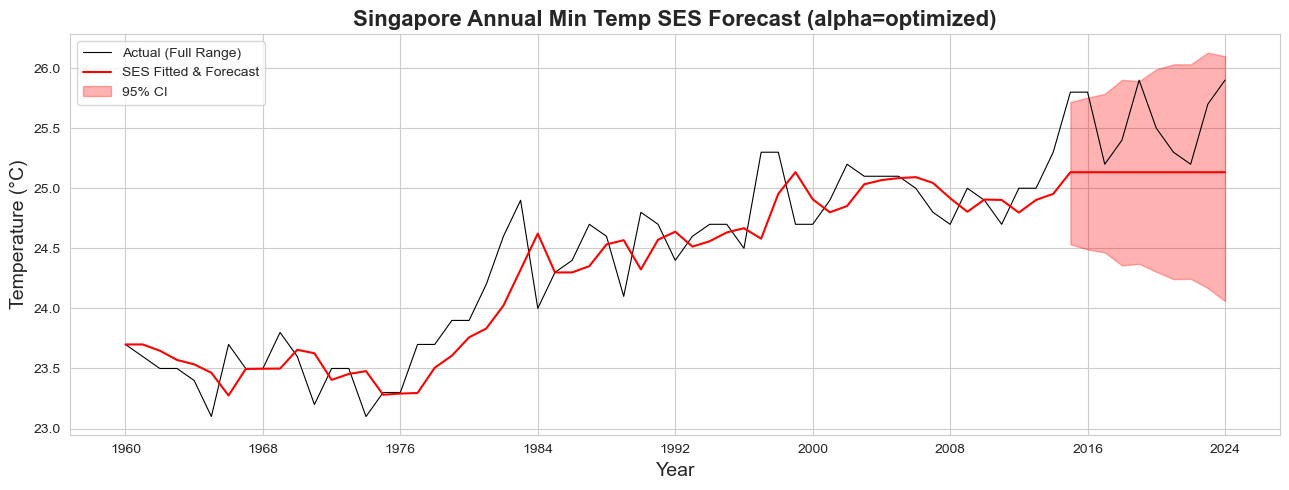

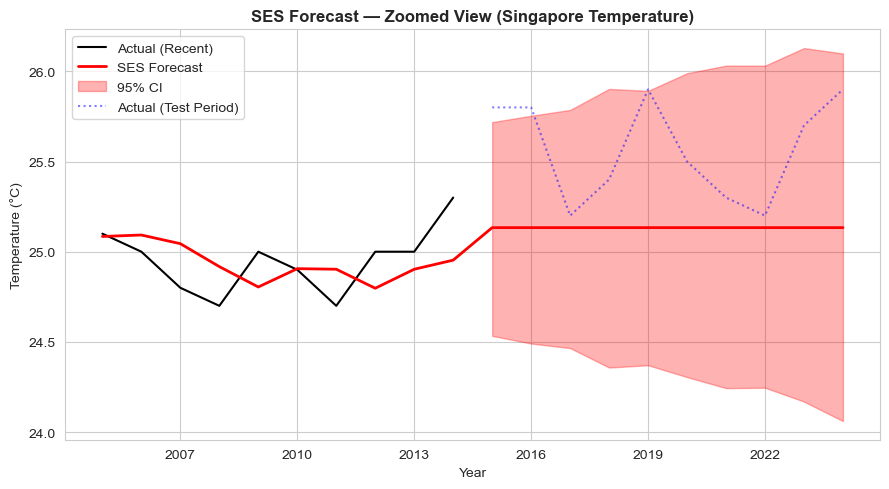

In [10]:
# 3.1 预测2015-2024年温度
train = data['Temp_Min'].loc[1960:2014]
test = data['Temp_Min'].loc[2015:2024]
fc_step = 10 

first_val = float(train.iloc[0])

ses_model = SimpleExpSmoothing(
    train,
    initialization_method='known',
    initial_level=first_val
).fit(
    optimized=True
)

optimized_alpha = ses_model.params['smoothing_level']

print('=== SES 模型参数 (自动优化) ===')
print(f'自动搜索到的最优 Alpha: {optimized_alpha:.4f}')
print(f'初始水平 Initial Level: {ses_model.params["initial_level"]:.4f}')
print()

# 生成预测值和未来时间轴
ses_forecast = ses_model.forecast(fc_step)
last_year = train.index[-1]
future_years = range(last_year + 1, last_year + 1 + fc_step)
ses_forecast.index = future_years
future_dates = ses_forecast.index

# 模拟置信区间
ses_ci = ses_model.simulate(fc_step, repetitions=1000, error='add')
ci_lower = ses_ci.quantile(0.025, axis=1)
ci_upper = ses_ci.quantile(0.975, axis=1)

# 全局绘图 
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot( data['Temp_Min'].index,  data['Temp_Min'], color='black', linewidth=0.8, label='Actual (Full Range)')
fitted_and_fc = pd.concat([ses_model.fittedvalues, ses_forecast])
ax.plot(fitted_and_fc.index, fitted_and_fc, color='red', linewidth=1.5, label='SES Fitted & Forecast')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.fill_between(future_dates, ci_lower, ci_upper, alpha=0.3, color='red', label='95% CI')

ax.set_title(f'Singapore Annual Min Temp SES Forecast (alpha=optimized)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Temperature (°C)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'SES_FullRange_Forecast_Comparison.png')
plt.show()

#局部放大图 
origts_incl = 10 
recent_actual = train.iloc[-origts_incl:]
recent_fitted = ses_model.fittedvalues.iloc[-origts_incl:]

fig, ax = plt.subplots(figsize=(9, 5))

# 历史最近10年 + 未来10年
short_fc = pd.concat([recent_fitted, ses_forecast])
ax.plot(recent_actual.index, recent_actual, color='black', label='Actual (Recent)')
ax.plot(short_fc.index, short_fc, color='red', linewidth=2, label='SES Forecast')
ax.fill_between(future_dates, ci_lower, ci_upper, alpha=0.3, color='red', label='95% CI')

# 2015-2024 实际数据对比
ax.plot(test.index, test, color='blue', alpha=0.5, linestyle=':', label='Actual (Test Period)')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title('SES Forecast — Zoomed View (Singapore Temperature)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°C)')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'SES_ZoomedView_TestPeriod_Evaluation.png')
plt.show()

In [11]:
# 3.2 打印报告
print(ses_model.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:               Temp_Min   No. Observations:                   55
Model:             SimpleExpSmoothing   SSE                              4.379
Optimized:                       True   AIC                           -135.174
Trend:                           None   BIC                           -131.160
Seasonal:                        None   AICC                          -134.374
Seasonal Periods:                None   Date:                 Thu, 16 Apr 2026
Box-Cox:                        False   Time:                         11:31:00
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5197119                alpha                 True
initial_level              23.700000                

In [12]:
# 3.2 拟合评估函数
def calc_metrics(pred, actual, name):
    resid = pred - actual
    
    mape = (abs(resid) / actual).mean() * 100
    mae  = abs(resid).mean()
    mse  = (resid ** 2).mean()
    rmse = np.sqrt(mse)  
    
    return {'模型': name, 
            'MAPE (%)': round(mape, 4),
            'MAE': round(mae, 4), 
            'MSE': round(mse, 4),
            'RMSE': round(rmse, 4)}

train_results = calc_metrics(ses_model.fittedvalues, train, 'SES(样本内)')
test_results = calc_metrics(ses_forecast, test, 'SES(样本外)')

results = pd.DataFrame([train_results, test_results]).set_index('模型')

print('=== SES 模型精度评估 ===')
print(results)


=== SES 模型精度评估 ===
          MAPE (%)     MAE     MSE    RMSE
模型                                        
SES(样本内)    0.8899  0.2167  0.0796  0.2822
SES(样本外)    1.6963  0.4365  0.2627  0.5125


## 4. ARIMA模型

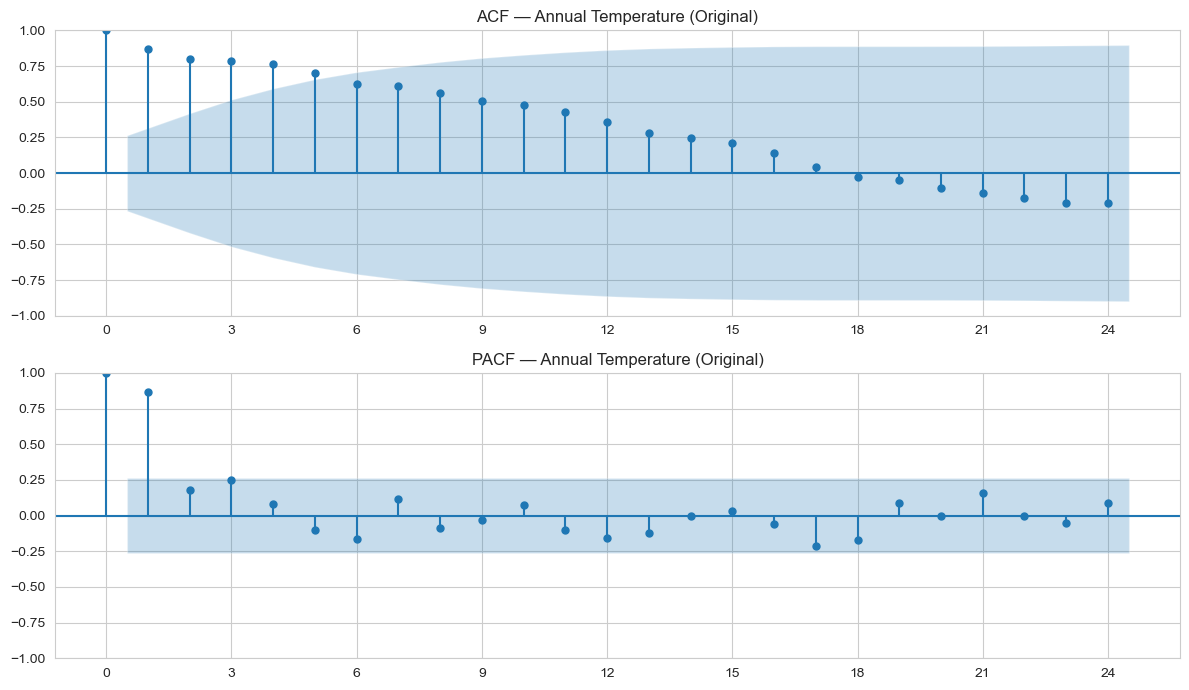

In [13]:
# 4.1 ACF图与PACF图
maxlag = 24
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(train, lags=maxlag, ax=axes[0], title='ACF — Annual Temperature (Original)')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
plot_pacf(train, lags=maxlag, ax=axes[1], title='PACF — Annual Temperature (Original)', method='ywm')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'TempMin_Original_ACF_PACF_Diagnosis.png')
plt.show()

ACF图没有快速收敛，还需要进行差分

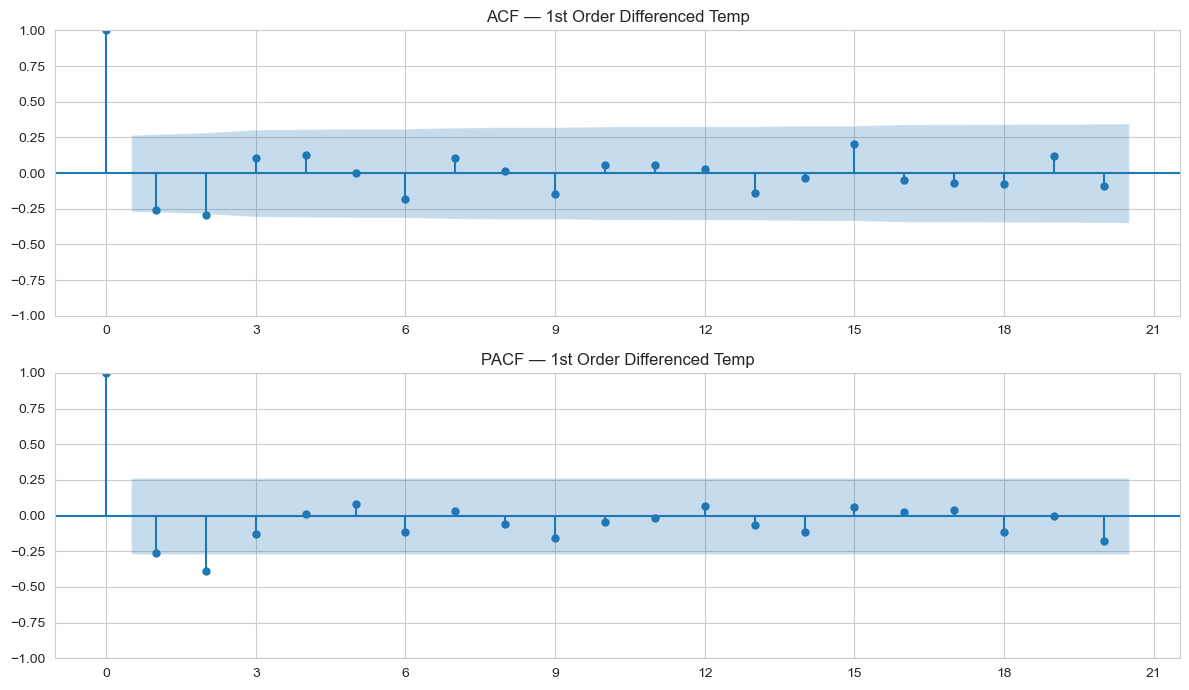

In [14]:
# 4.2 一阶差分后的ACF图和PACF图
train_diff = train.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(train_diff, ax=axes[0], lags=20, title='ACF — 1st Order Differenced Temp')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
plot_pacf(train_diff, ax=axes[1], lags=20, title='PACF — 1st Order Differenced Temp', method='ywm')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'TempMin_Diff1_ACF_PACF_Diagnosis.png')
plt.show()

根据上图，参数可设置为
    (1, 1, 0), 
    (2, 1, 0), 
    (0, 1, 1), 
  

In [15]:
# 4.3 各参数 ARIMA 模型对比
candidates = [
    (1, 1, 0), 
    (2, 1, 0), 
    (0, 1, 1), 
]

results = []

for order in candidates:
    try:
        model = ARIMA(train, order=order).fit()
        pvals = model.pvalues.drop('drift', errors='ignore')
        all_sig = (pvals < 0.05).all()
        
        results.append({
            '模型': f'ARIMA{order}',
            'AIC': round(model.aic, 2),
            '全部显著': all_sig
        })
    except Exception as e:
        results.append({
            '模型': f'ARIMA{order}',
            'AIC': np.inf,
            '全部显著': f'错误: {e}'
        })

comparison = pd.DataFrame(results).sort_values('AIC')

print('=== ARIMA 模型对比表 (AIC 越小越好) ===')
print(comparison.to_string(index=False))

valid_models = comparison[comparison['全部显著'] == True]
if not valid_models.empty:
    best_model_name = valid_models.iloc[0]['模型']
    print(f"\n推荐的最优显著模型为: {best_model_name}")
else:
    print("\n未找到所有参数均显著的模型,请考虑简化阶数!")

=== ARIMA 模型对比表 (AIC 越小越好) ===
            模型   AIC  全部显著
ARIMA(2, 1, 0) 20.49  True
ARIMA(0, 1, 1) 21.76  True
ARIMA(1, 1, 0) 26.30 False

推荐的最优显著模型为: ARIMA(2, 1, 0)


In [16]:
# 4.4 拟合最优参数，查看p值
arima_best = ARIMA(
    train,
    order=(2, 1, 0)
).fit()
print(arima_best.summary())

                               SARIMAX Results                                
Dep. Variable:               Temp_Min   No. Observations:                   55
Model:                 ARIMA(2, 1, 0)   Log Likelihood                  -7.245
Date:                Thu, 16 Apr 2026   AIC                             20.489
Time:                        11:31:00   BIC                             26.456
Sample:                             0   HQIC                            22.791
                                 - 55                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3469      0.148     -2.338      0.019      -0.638      -0.056
ar.L2         -0.3642      0.145     -2.516      0.012      -0.648      -0.081
sigma2         0.0761      0.014      5.260      0.0

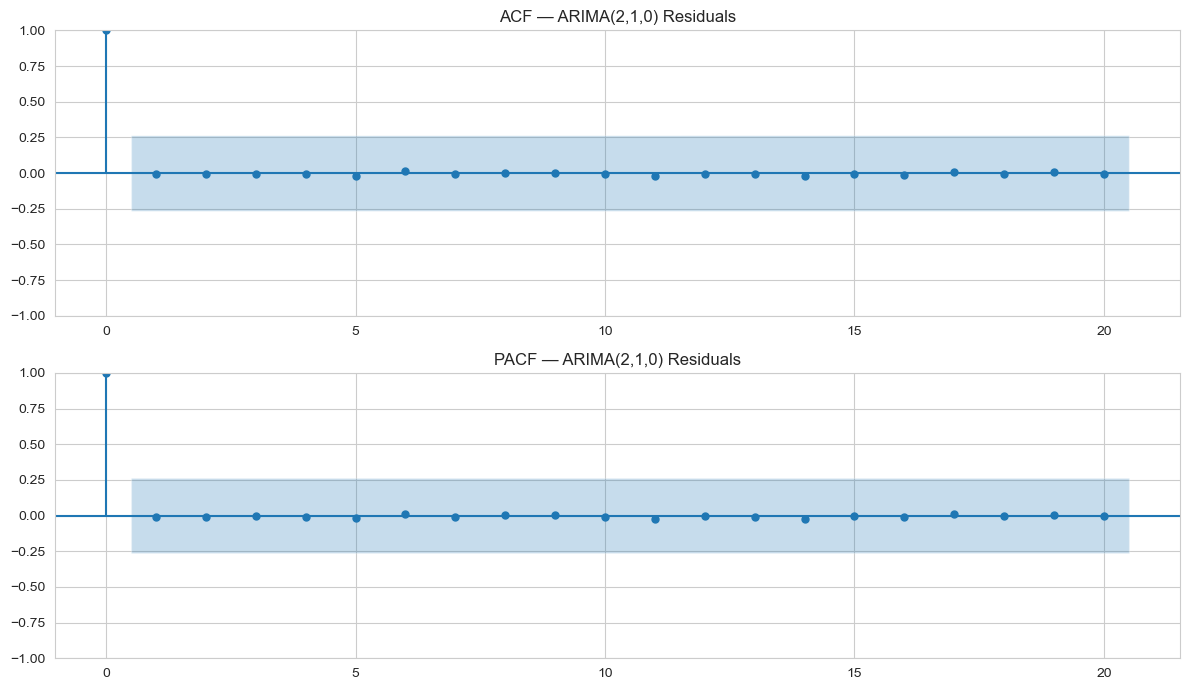

In [17]:
# 4.5 残差诊断
arima_res = arima_best.resid

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(arima_res,  lags=20, ax=axes[0], title='ACF — ARIMA(2,1,0) Residuals')
plot_pacf(arima_res, lags=20, ax=axes[1], title='PACF — ARIMA(2,1,0) Residuals', method='ywm')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ARIMA210_Residuals_ACF_PACF_Diagnosis.png')
plt.show()

Shapiro-Wilk 检验：W = 0.9786,  p = 4.4434e-01


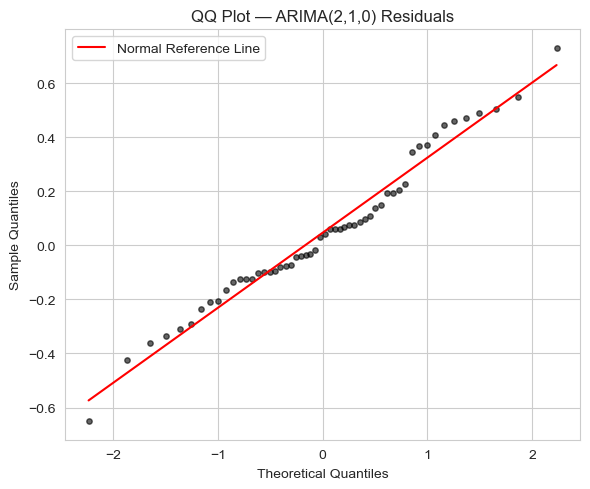

In [18]:
# 4.6 残差QQ图
arima_res = arima_best.resid[1:] 

# --- 2. 进行正态性检验 ---
from scipy import stats
stat, p_val = stats.shapiro(arima_res)
print(f'Shapiro-Wilk 检验：W = {stat:.4f},  p = {p_val:.4e}')

# --- 3. 绘制 QQ 图 ---
fig, ax = plt.subplots(figsize=(6, 5))
# stats.probplot 会根据传入的 arima_res 自动计算分位数
(theoretical_q, actual_q), (slope, intercept, r) = stats.probplot(arima_res, dist='norm')

ax.scatter(theoretical_q, actual_q, s=15, color='black', alpha=0.6)
x_line = np.array([theoretical_q[0], theoretical_q[-1]])
ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5, label='Normal Reference Line')

ax.set_title('QQ Plot — ARIMA(2,1,0) Residuals')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ARIMA210_Residuals_QQ_Plot.png')
plt.show()


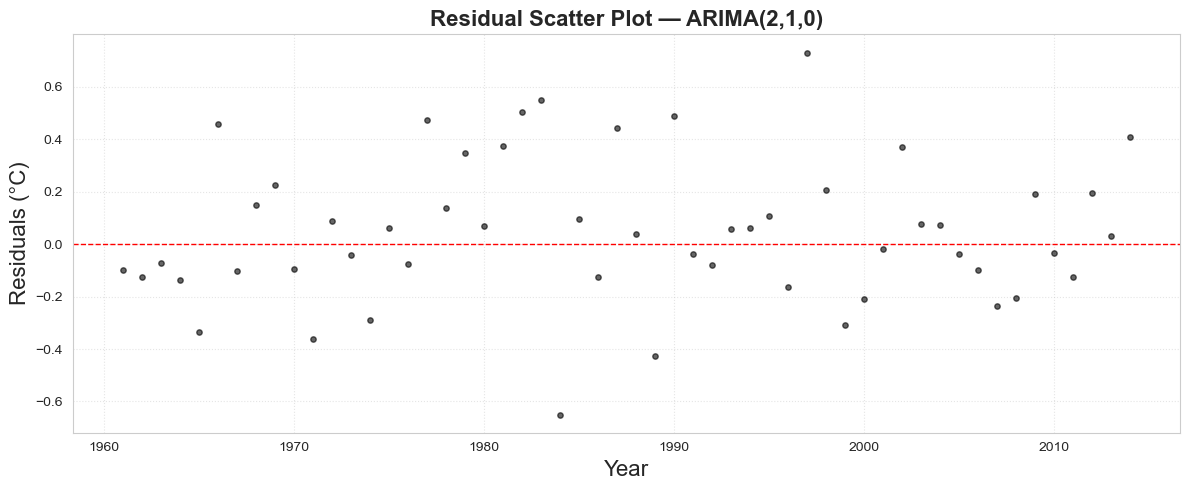

In [19]:
# 4.7 残差散点图
fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(train.index[1:], arima_res, s=15, color='black', alpha=0.6)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Residual Scatter Plot — ARIMA(2,1,0)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year',fontsize=16)
ax.set_ylabel('Residuals (°C)',fontsize=16)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ARIMA210_Residuals_Scatter_Plot.png')
plt.show()

2015-2024 预测均值：
2015    25.195920
2016    25.122759
2017    25.186050
2018    25.190740
2019    25.166060
2020    25.172914
2021    25.179526
2022    25.174736
2023    25.173989
2024    25.175993
Name: predicted_mean, dtype: float64


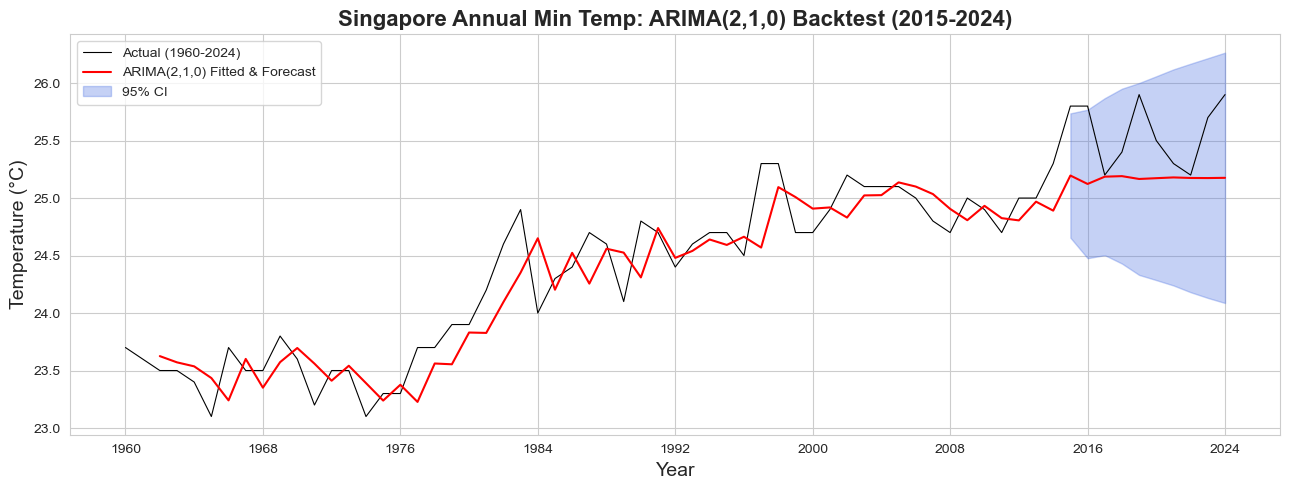

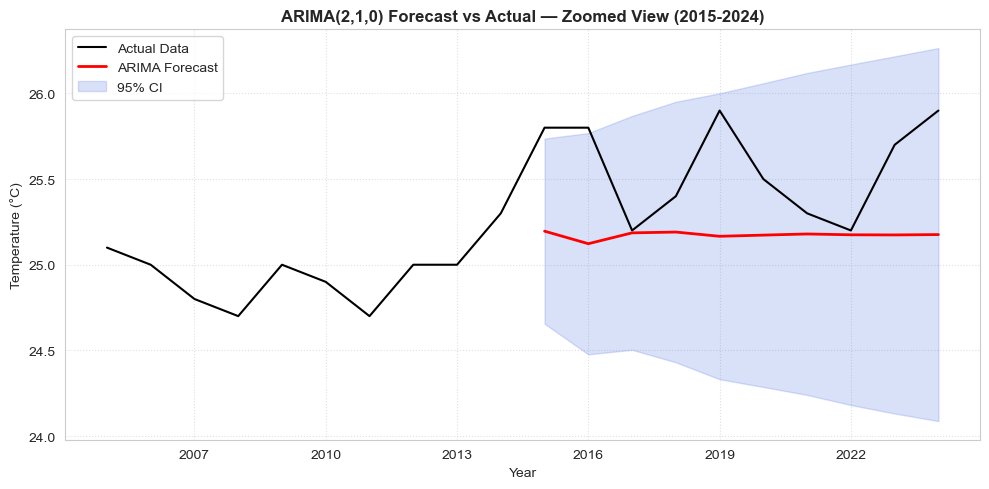

In [20]:
# 4.8 预测2015-2024年温度
fc_step = 10 

fc = arima_best.get_forecast(steps=fc_step)
fc_pred = fc.predicted_mean

fc_ci = fc.conf_int(alpha=0.05)
fc_cil = fc_ci.iloc[:, 0]
fc_ciu = fc_ci.iloc[:, 1]

future_years = np.arange(2015, 2015 + fc_step)
fc_pred.index = future_years
fc_cil.index = future_years
fc_ciu.index = future_years

print('2015-2024 预测均值：')
print(fc_pred)

# 完整序列 + 预测对比图
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(data.index, data['Temp_Min'], color='black', linewidth=0.8, label='Actual (1960-2024)')
fitted_clean = arima_best.fittedvalues[2:] 
fitted_and_fc = pd.concat([fitted_clean, fc_pred])
ax.plot(fitted_and_fc.index, fitted_and_fc, color='red', linewidth=1.5, label='ARIMA(2,1,0) Fitted & Forecast')

ax.fill_between(future_years, fc_cil, fc_ciu, alpha=0.3, color='royalblue', label='95% CI')
ax.set_title('Singapore Annual Min Temp: ARIMA(2,1,0) Backtest (2015-2024)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Temperature (°C)', fontsize=14)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ARIMA210_FullRange_Backtest_Plot.png')
plt.show()

# 局部放大图（2005-2024：预测集与测试集对比）
fig, ax = plt.subplots(figsize=(10, 5))

recent_actual = data['Temp_Min'].loc[2005:2024]
ax.plot(recent_actual.index, recent_actual, color='black', markersize=4, label='Actual Data')
ax.plot(fc_pred.index, fc_pred, color='red', linewidth=2, label='ARIMA Forecast')
ax.fill_between(future_years, fc_cil, fc_ciu, alpha=0.2, color='royalblue', label='95% CI')
ax.set_title('ARIMA(2,1,0) Forecast vs Actual — Zoomed View (2015-2024)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ARIMA210_Forecast_vs_Actual_Zoomed.png')
plt.show()


=== 预测精度对比汇总 (2015–2024 样本外测试集) ===
                MAPE (%)     MAE    RMSE  AIC (in-sample)
模型                                                       
SES (Baseline)    1.6963  0.4365  0.5125          -135.17
ARIMA(2,1,0)      1.5381  0.3961  0.4826            20.49


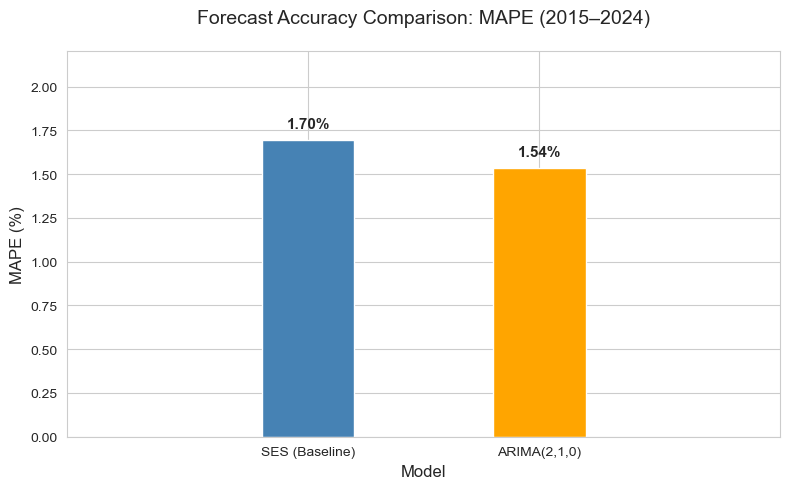

In [21]:
# 3.9 评估简单指数平滑模型与ARIMA模型
def eval_forecast(pred, actual, model_name, aic_val=None):
    """计算预测精度指标"""
    common_idx = pred.index.intersection(actual.index)
    p = pred.loc[common_idx]
    a = actual.loc[common_idx]
    resid = p - a

    mape = (abs(resid) / a).mean() * 100
    mae  = abs(resid).mean()
    mse  = (resid ** 2).mean()
    rmse = np.sqrt((resid ** 2).mean())
    
    row = {
        '模型': model_name,
        'MAPE (%)': round(mape, 4),
        'MAE': round(mae, 4), 
        'RMSE': round(rmse, 4), 
    }
    if aic_val is not None:
        row['AIC (in-sample)'] = round(aic_val, 2)
    return row

metrics_list = [
    eval_forecast(ses_forecast, test, 'SES (Baseline)', aic_val=ses_model.aic),
    eval_forecast(fc_pred,      test, 'ARIMA(2,1,0)',   aic_val=arima_best.aic),
]

comparison_df = pd.DataFrame(metrics_list).set_index('模型')

print('\n' + '='*55)
print('=== 预测精度对比汇总 (2015–2024 样本外测试集) ===')
print('='*55)
print(comparison_df.to_string())

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['steelblue', 'orange']
bars = ax.bar(comparison_df.index, comparison_df['MAPE (%)'], color=colors[:len(comparison_df)], width=0.4)
ax.margins(x=0.6) 
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            height + 0.05, 
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Forecast Accuracy Comparison: MAPE (2015–2024)', fontsize=14, pad=20)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)

ax.set_ylim(0, comparison_df['MAPE (%)'].max() * 1.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Model_Comparison_MAPE_2015-2024.png')
plt.show()

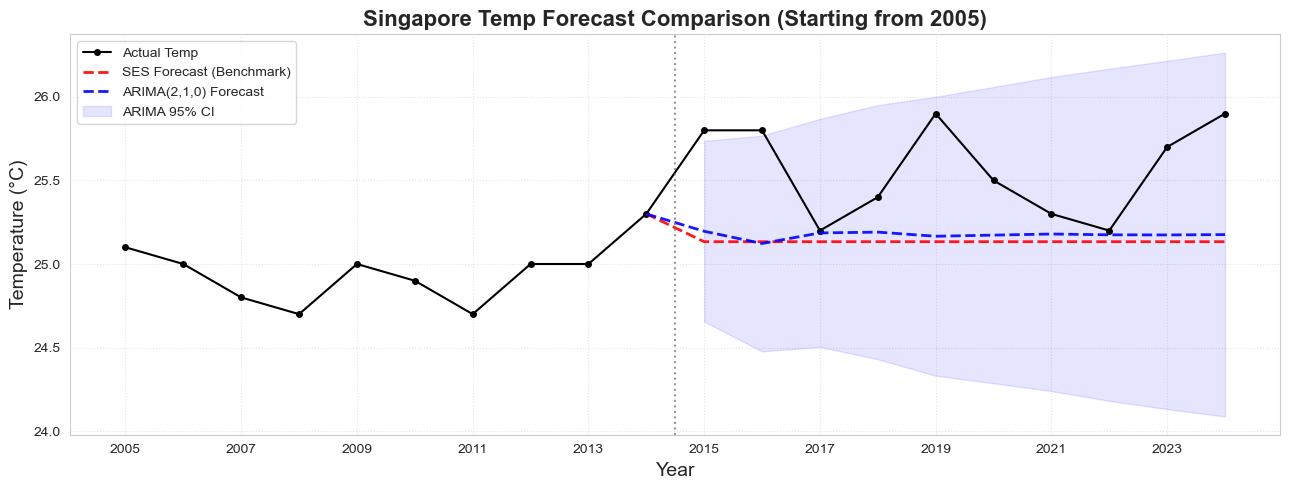

In [22]:
# 4.10  预测对比图
hist_actual = data['Temp_Min'].loc[2005:2014]

plt.figure(figsize=(13, 5))

full_actual = data['Temp_Min'].loc[2005:2024]
plt.plot(full_actual.index, full_actual.values, 'k-o', label='Actual Temp', linewidth=1.5, markersize=4)
ses_path = pd.concat([hist_actual.tail(1), ses_forecast])
plt.plot(ses_path.index, ses_path.values, 'r--', label='SES Forecast (Benchmark)', alpha=0.9, linewidth=2)
arima_path = pd.concat([hist_actual.tail(1), fc_pred])
plt.plot(arima_path.index, arima_path.values, 'b--', label='ARIMA(2,1,0) Forecast', alpha=0.9, linewidth=2)

plt.fill_between(fc_pred.index, fc_cil, fc_ciu, color='blue', alpha=0.1, label='ARIMA 95% CI')

plt.axvline(x=2014.5, color='gray', linestyle=':', alpha=0.8) 

plt.title('Singapore Temp Forecast Comparison (Starting from 2005)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.xticks(range(2005, 2025, 2))
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'SES_vs_ARIMA210_Forecast_Comparison.png')
plt.show()

--- 2025-2030 气温预测值 ---
      Mean_Temp  Lower_CI  Upper_CI
2025    25.64      25.08     26.20 
2026    25.63      24.93     26.32 
2027    25.74      25.01     26.46 
2028    25.71      24.92     26.51 
2029    25.67      24.79     26.56 
2030    25.69      24.76     26.63 


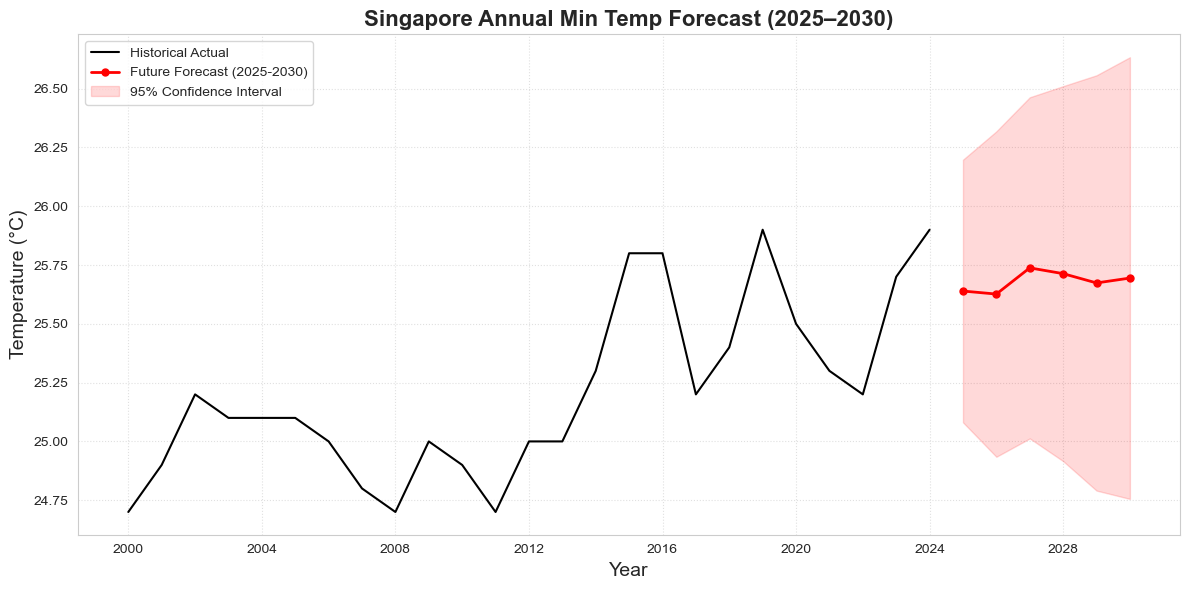

In [23]:
# 4.11 ARIMA模型预测2025年到2030年温度
final_model_full = ARIMA(data['Temp_Min'], order=(2, 1, 0)).fit()

fc_step_future = 6
forecast_future = final_model_full.get_forecast(steps=fc_step_future)
fc_mean_future = forecast_future.predicted_mean
fc_ci_future = forecast_future.conf_int(alpha=0.05) 

future_years_idx = np.arange(2025, 2025 + fc_step_future)
fc_mean_future.index = future_years_idx
fc_ci_future.index = future_years_idx

print("--- 2025-2030 气温预测值 ---")
forecast_df = pd.concat([fc_mean_future, fc_ci_future], axis=1)
forecast_df.columns = ['Mean_Temp', 'Lower_CI', 'Upper_CI']
print(forecast_df.round(2).to_string(justify='center'))

fig, ax = plt.subplots(figsize=(12, 6))

recent_history = data['Temp_Min'].loc[2000:]
ax.plot(recent_history.index, recent_history, color='black', label='Historical Actual')
ax.plot(fc_mean_future.index, fc_mean_future, color='red', linewidth=2, marker='o', markersize=5, label='Future Forecast (2025-2030)')
ax.fill_between(future_years_idx, 
                fc_ci_future.iloc[:, 0], 
                fc_ci_future.iloc[:, 1], 
                color='red', alpha=0.15, label='95% Confidence Interval')

ax.set_title('Singapore Annual Min Temp Forecast (2025–2030)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Temperature (°C)', fontsize=14)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ARIMA_MinTemp_Future_Forecast_2030.png')
plt.show()

# 5. 动态回归模型

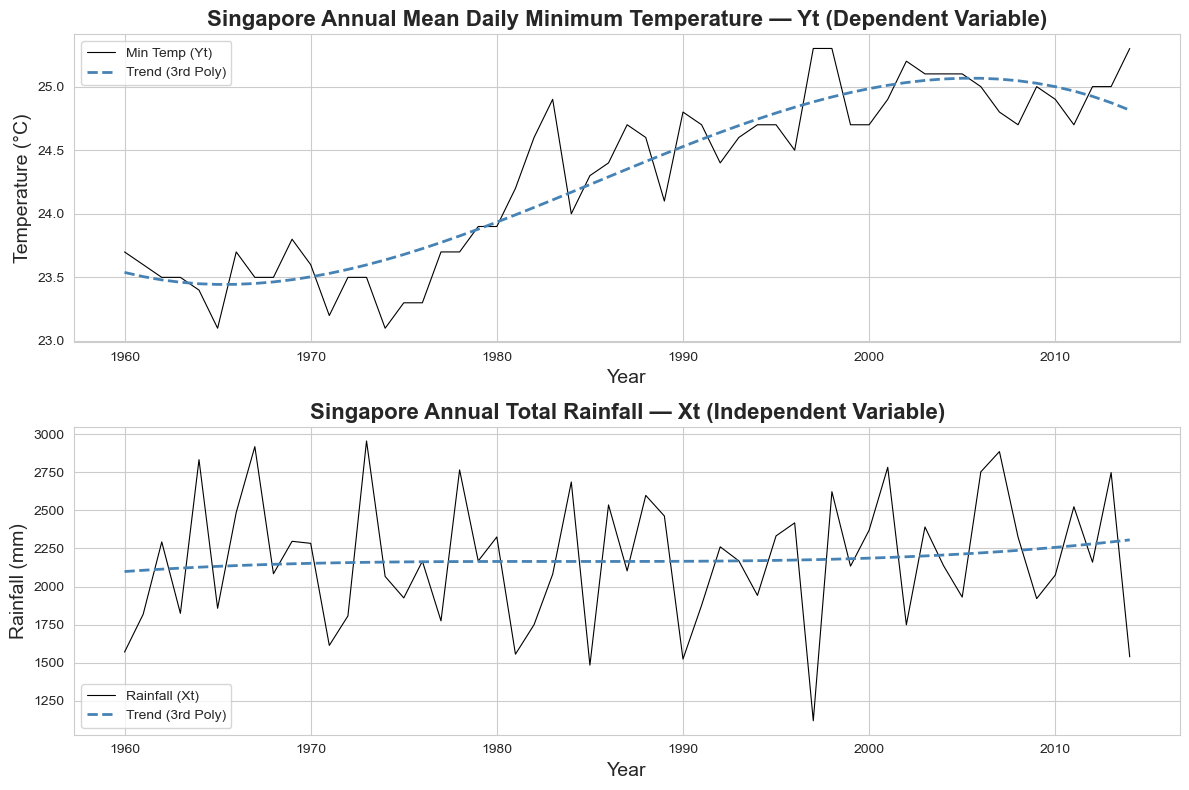

In [24]:
# 5.1 时间序列对比图
xt = data['Rainfall']
yt = data['Temp_Min']
yt_train = yt.loc[1960:2014]
xt_train = xt.loc[1960:2014]
yt_test = yt.loc[2015:2024]
xt_test = xt.loc[2015:2024]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(yt_train.index, yt_train, color='black', linewidth=0.8, label='Min Temp (Yt)')
z_temp = np.polyfit(yt_train.index,yt_train, 3)
axes[0].plot(yt_train.index, np.poly1d(z_temp)(yt_train.index),
             color='steelblue', linewidth=2, linestyle='--', label='Trend (3rd Poly)')
axes[0].set_title('Singapore Annual Mean Daily Minimum Temperature — Yt (Dependent Variable)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=14)
axes[0].set_ylabel('Temperature (°C)', fontsize=14)
axes[0].legend()

axes[1].plot(xt_train.index, xt_train, color='black', linewidth=0.8, label='Rainfall (Xt)')
z_rain = np.polyfit(xt_train.index, xt_train, 3)
axes[1].plot(xt_train.index, np.poly1d(z_rain)(xt_train.index),
             color='steelblue', linewidth=2, linestyle='--', label='Trend (3rd Poly)')
axes[1].set_title('Singapore Annual Total Rainfall — Xt (Independent Variable)', fontsize=16,fontweight='bold')
axes[1].set_xlabel('Year',fontsize=14)
axes[1].set_ylabel('Rainfall (mm)',fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Temp_Rainfall_Comparison_Trend_1960-2014.png')
plt.show()

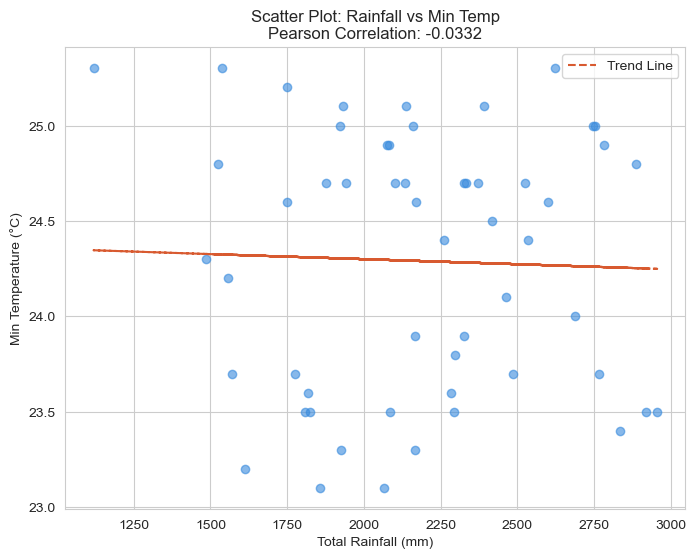

降雨量与最低气温的 Pearson 相关系数为: -0.0332


In [25]:
# 5.2 散点图与相关系数
correlation = yt_train.corr(xt_train)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(xt_train, yt_train, alpha=0.6, color='#378ADD')
m, b = np.polyfit(xt_train, yt_train, 1)
ax.plot(xt_train, m*xt_train + b, color='#D85A30', linestyle='--', label='Trend Line')

ax.set_title(f'Scatter Plot: Rainfall vs Min Temp\nPearson Correlation: {correlation:.4f}')
ax.set_xlabel('Total Rainfall (mm)')
ax.set_ylabel('Min Temperature (°C)')
ax.legend()
plt.savefig(OUTPUT_DIR / 'Rainfall_vs_Temp_Scatter_Correlation.png')
plt.show()

# 计算 yt_train 和 xt_train 之间的相关系数
correlation = yt_train.corr(xt_train)
print(f"降雨量与最低气温的 Pearson 相关系数为: {correlation:.4f}")

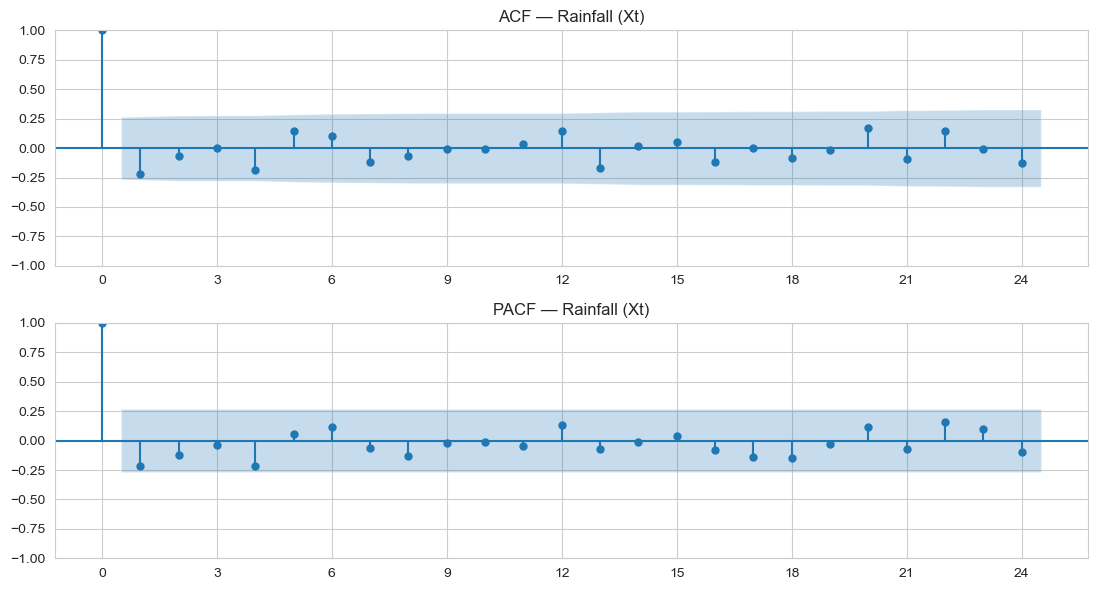

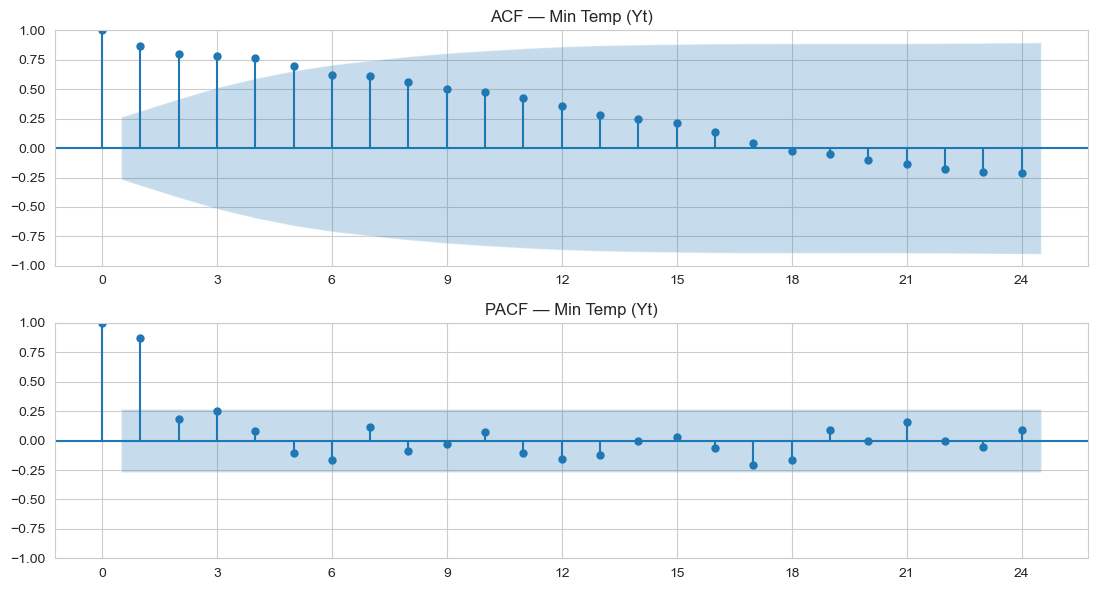

In [26]:
# 5.3 自相关诊断
maxlag = 24

for series_data, name in [(xt_train, 'Rainfall (Xt)'),(yt_train, 'Min Temp (Yt)')]:
    fig, axes = plt.subplots(2, 1, figsize=(11, 6))
    
    plot_acf(series_data, lags=maxlag, ax=axes[0], title=f'ACF — {name}')
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True)) 
    
    plot_pacf(series_data, lags=maxlag, ax=axes[1], title=f'PACF — {name}', method='ywm')
    axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    
    plt.tight_layout()
     
    clean_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    save_path = OUTPUT_DIR / f'ACF_PACF_{clean_name}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

根据ACF和PACF图显示，Rainfall除滞后0阶外，所有阶数的自相关系数和偏自相关系数均落在置信区间内。这表明 Rainfall(Xt)序列的自相关性均不显著,呈现出明显的白噪声特征。

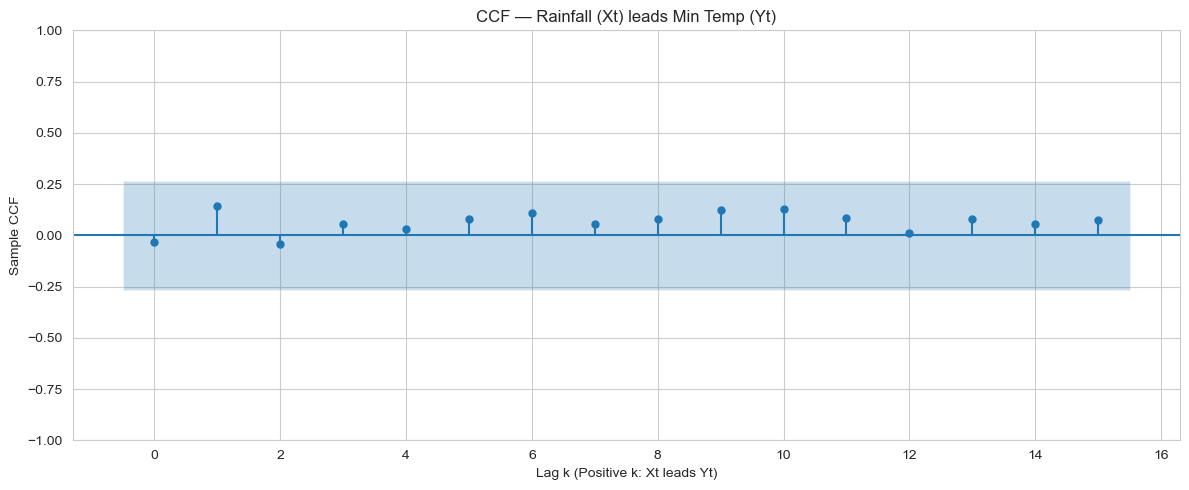

95% 置信区间边界：±0.2431
各滞后阶数的 CCF 值（判断 Xt 是否影响 Yt）：
  lag  0: -0.1282  
  lag  1:  0.0240  
  lag  2: -0.0906  
  lag  3: -0.0444  
  lag  4: -0.0508  
  lag  5:  0.0326  
  lag  6:  0.0560  
  lag  7:  0.0275  
  lag  8:  0.0605  
  lag  9:  0.0719  
  lag 10:  0.0486  
  lag 11:  0.0195  
  lag 12: -0.0559  
  lag 13: -0.0312  
  lag 14: -0.0311  
  lag 15: -0.0015  


In [27]:
# 5.4 互相关诊断
fig, ax = plt.subplots(figsize=(12, 5))

plot_ccf(xt_train, yt_train, lags=15, ax=ax, title='CCF — Rainfall (Xt) leads Min Temp (Yt)')

ax.set_xlabel('Lag k (Positive k: Xt leads Yt)')
ax.set_ylabel('Sample CCF')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Rainfall_Leads_MinTemp_CCF_Analysis.png')
plt.show()

ccf_vals = ccf_func(xt, yt)[:16]
ci = 1.96 / np.sqrt(len(yt))

print(f'95% 置信区间边界：±{ci:.4f}')
print('各滞后阶数的 CCF 值（判断 Xt 是否影响 Yt）：')
for k, v in enumerate(ccf_vals):
    sig = '*** 显著' if abs(v) > ci else ''
    print(f'  lag {k:2d}: {v:7.4f}  {sig}')

当前的 CCF 值不显著，为了展示分析思路，创建5阶的滞后项来放入回归模型中观察，用以捕捉微弱但累积的效应

In [28]:
# 5.5 构建滞后项
dynreg = pd.DataFrame({
    'yt' : yt_train,
    'xt0': xt_train.shift(0),
    'xt1': xt_train.shift(1),
    'xt2': xt_train.shift(2),
    'xt3': xt_train.shift(3),
    'xt4': xt_train.shift(4),
    'xt5': xt_train.shift(5),
})

dynreg = dynreg.dropna()

print(f'训练集有效数据：{len(dynreg)} 行 (从 {dynreg.index[0]} 到 {dynreg.index[-1]})')
dynreg.head()

训练集有效数据：50 行 (从 1965 到 2014)


,yt,xt0,xt1,xt2,xt3,xt4,xt5
Year,,,,,,,
1965,23.1,1857.2,2833.2,1824.1,2293.2,1817.6,1569.6
1966,23.7,2486.9,1857.2,2833.2,1824.1,2293.2,1817.6
1967,23.5,2918.8,2486.9,1857.2,2833.2,1824.1,2293.2
1968,23.5,2084.2,2918.8,2486.9,1857.2,2833.2,1824.1
1969,23.8,2297.1,2084.2,2918.8,2486.9,1857.2,2833.2


In [29]:
# 5.6 计算yt与各阶滞后xt的相关性
for i in range(6):
    corr_lag = yt_train.corr(xt_train.shift(i))
    print(f"y_t 与 x_{{t-{i}}} 的相关系数: {corr_lag:.4f}")

y_t 与 x_{t-0} 的相关系数: -0.0332
y_t 与 x_{t-1} 的相关系数: -0.0135
y_t 与 x_{t-2} 的相关系数: 0.1142
y_t 与 x_{t-3} 的相关系数: 0.1140
y_t 与 x_{t-4} 的相关系数: 0.0665
y_t 与 x_{t-5} 的相关系数: 0.0274


In [30]:
# 5.7 拟合结果
dyr0 = smf.ols('yt ~ xt0 + xt1 + xt2 + xt3 + xt4 + xt5 - 1',
               data=dynreg).fit()
print('=== 第 0 轮：所有变量 ===')
print(dyr0.summary().tables[1])  

=== 第 0 轮：所有变量 ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
xt0            0.0014      0.000      2.995      0.004       0.000       0.002
xt1            0.0019      0.000      4.507      0.000       0.001       0.003
xt2            0.0021      0.000      4.797      0.000       0.001       0.003
xt3            0.0021      0.000      4.942      0.000       0.001       0.003
xt4            0.0020      0.000      4.662      0.000       0.001       0.003
xt5            0.0015      0.000      3.199      0.003       0.001       0.002


考虑到气象系统中的能量循环存在跨年度的延迟效应（例如土壤湿度的记忆性），我选择 5 阶滞后项 (xt5) 建立基础回归模型。

In [31]:
# 5.8 最终线性模型
yt_lm = smf.ols('yt ~ xt0 + xt1 + xt2 + xt3 + xt4 + xt5- 1', data=dynreg).fit()
print('=== 最终线性模型 ===')
print(yt_lm.summary())

=== 最终线性模型 ===
                                 OLS Regression Results                                
Dep. Variable:                     yt   R-squared (uncentered):                   0.997
Model:                            OLS   Adj. R-squared (uncentered):              0.996
Method:                 Least Squares   F-statistic:                              2317.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):                    2.62e-53
Time:                        11:31:03   Log-Likelihood:                         -86.661
No. Observations:                  50   AIC:                                      185.3
Df Residuals:                      44   BIC:                                      196.8
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

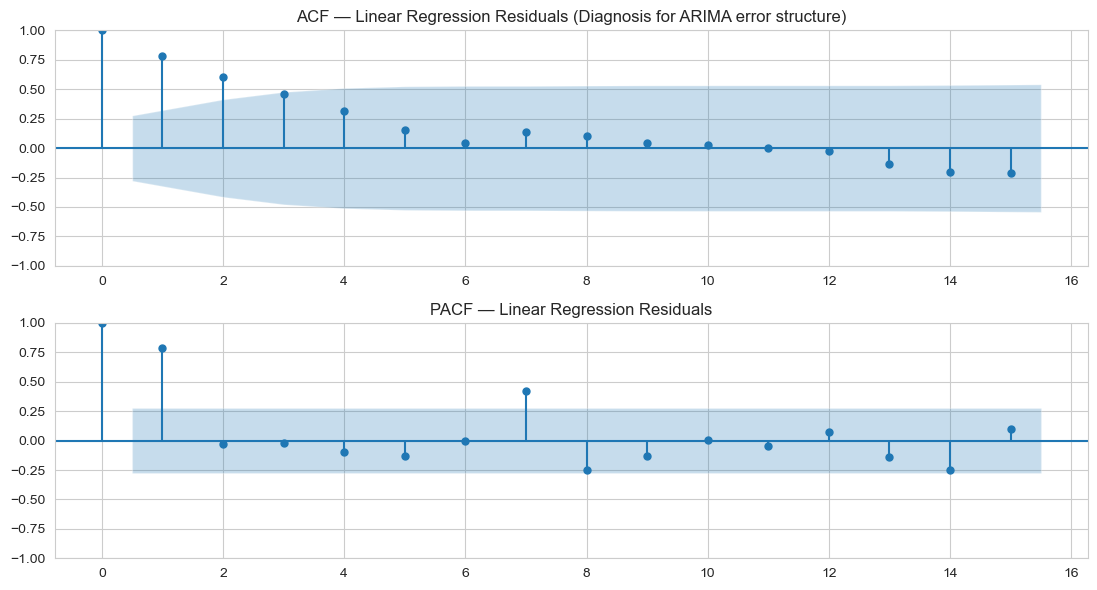

In [32]:
# 5.9 提取线性回归模型的残差
lm_res = yt_lm.resid

fig, axes = plt.subplots(2, 1, figsize=(11, 6))

plot_acf(lm_res, lags=15, ax=axes[0],
         title='ACF — Linear Regression Residuals (Diagnosis for ARIMA error structure)')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True)) 
plot_pacf(lm_res, lags=15, ax=axes[1],
          title='PACF — Linear Regression Residuals', method='ywm')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Linear_Regression_Residuals_ACF_PACF_Diagnosis.png')
plt.show()

# 3. 结果解读（用于你的报告）
# 如果你观察到 PACF 只有第 1 阶显著，而 ACF 缓慢衰减
# 这证实了误差项 (Error Term) 适合用 AR(1) 模型描述
# 那么下一步动态回归 (ARIMAX) 的参数就是 order=(1, 0, 0)


PACF 除了第 1 阶显著，在 7 阶处也出现了显著跳跃，残差可能存在约 7 年的潜在周期性。基于简约建模原则，我初步方案将优先设定误差项为 ARIMA(1, 0, 0)；若模型诊断显示残差仍非白噪声，则将进一步考虑引入高阶项或移动平均项来修正这种长程相关性。
因此ARIMAX的 order=(1, 0, 0)

In [33]:
# 5.10 外生变量矩阵
exog_train = dynreg[['xt0', 'xt1', 'xt2', 'xt3', 'xt4', 'xt5']]
endog_train = dynreg['yt']


arimax_model = ARIMA(endog_train, 
                     exog=exog_train, 
                     order=(1, 0, 0), 
                     trend='c').fit()

print('=== 动态回归模型 (ARIMAX) 估计结果 ===')
print(arimax_model.summary())

=== 动态回归模型 (ARIMAX) 估计结果 ===
                               SARIMAX Results                                
Dep. Variable:                     yt   No. Observations:                   50
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  -5.291
Date:                Thu, 16 Apr 2026   AIC                             28.583
Time:                        11:31:04   BIC                             45.791
Sample:                             0   HQIC                            35.136
                                 - 50                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.0675      1.579     15.239      0.000      20.972      27.163
xt0           -0.0002      0.000     -2.303      0.021      -0.000   -3.56e-05
xt1           -0.0002  

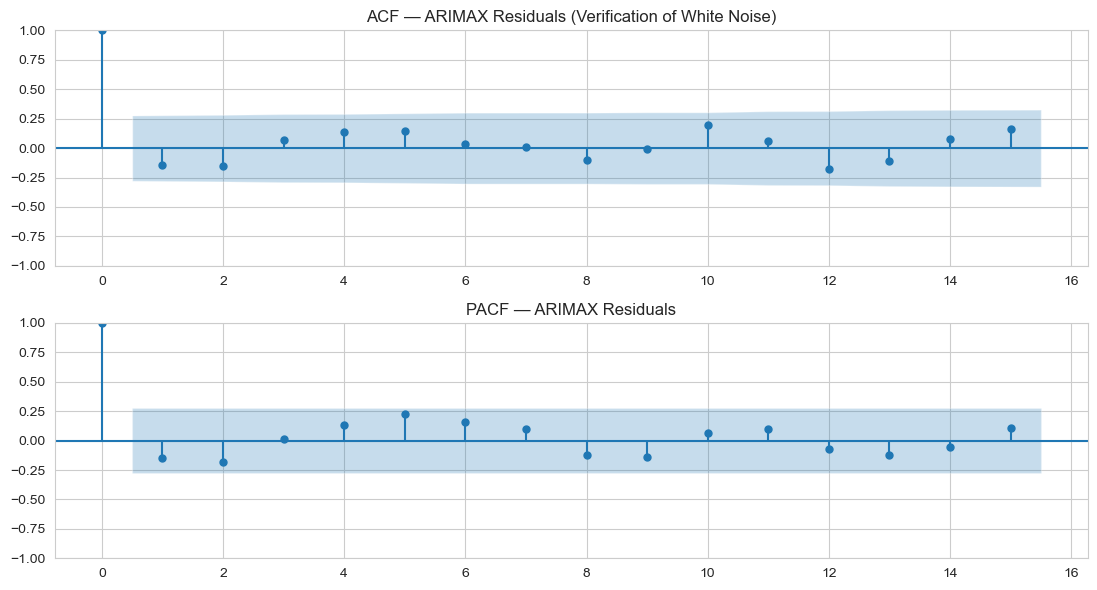

--- Ljung-Box 检验 (P > 0.05 则说明残差是白噪声) ---
     lb_stat  lb_pvalue
10  8.262254   0.603237


In [34]:
# 5.11 ARIMAX 模型残差诊断 (验证白噪声)
arimax_res = arimax_model.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 6))

plot_acf(arimax_res, lags=15, ax=axes[0], 
         title='ACF — ARIMAX Residuals (Verification of White Noise)')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True)) 

plot_pacf(arimax_res, lags=15, ax=axes[1], 
          title='PACF — ARIMAX Residuals', method='ywm')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()

plt.savefig(OUTPUT_DIR / 'ARIMAX_Final_Residual_Diagnosis.png')
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(arimax_res, lags=[10], return_df=True)
print("--- Ljung-Box 检验 (P > 0.05 则说明残差是白噪声) ---")
print(lb_test)

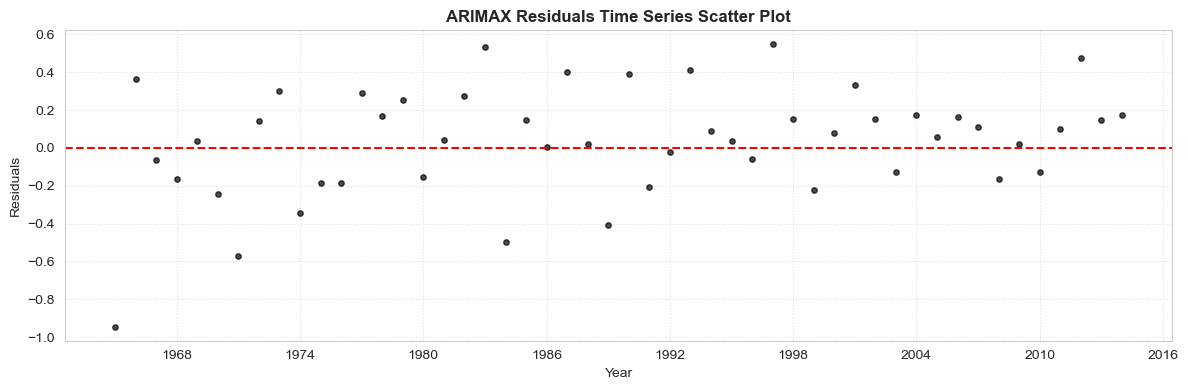

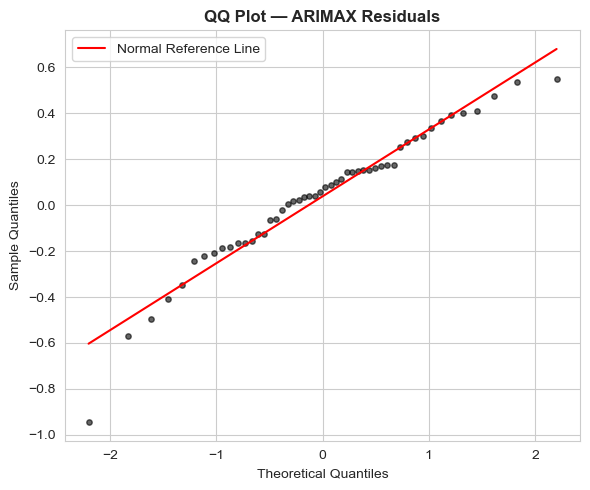

--- Shapiro-Wilk 正态性检验 ---
W 统计量: 0.9575
P-value: 6.9616e-02


In [39]:
# 5.12 残差散点图和QQ 图
fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(arimax_res.index, arimax_res.values, s=15, color='black', alpha=0.7)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Baseline')

ax.set_title('ARIMAX Residuals Time Series Scatter Plot', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Residuals')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ARIMAX_Residuals_TimeScatter.png')
plt.show()


fig, ax = plt.subplots(figsize=(6, 5))

(theoretical_q, actual_q), (slope, intercept, r) = stats.probplot(arimax_res, dist='norm')

ax.scatter(theoretical_q, actual_q, s=15, color='black', alpha=0.6)
x_line = np.array([theoretical_q[0], theoretical_q[-1]])
ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5, label='Normal Reference Line')

ax.set_title('QQ Plot — ARIMAX Residuals', fontweight='bold')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ARIMAX_Residuals_QQ_Plot.png')
plt.show()

stat, p_val = stats.shapiro(arimax_res)
print(f'--- Shapiro-Wilk 正态性检验 ---')
print(f'W 统计量: {stat:.4f}')
print(f'P-value: {p_val:.4e}')

In [36]:
# 5.13 预测测试集
exog_all = pd.DataFrame({
    'xt0': data['Rainfall'].shift(0),
    'xt1': data['Rainfall'].shift(1),
    'xt2': data['Rainfall'].shift(2),
    'xt3': data['Rainfall'].shift(3),
    'xt4': data['Rainfall'].shift(4),
    'xt5': data['Rainfall'].shift(5),
})

exog_test = exog_all.loc[2015:2024]
yt_test = data['Temp_Min'].loc[2015:2024]

print("测试集外生变量准备就绪，行数：", len(exog_test))

fc_arimax = arimax_model.get_forecast(steps=10, exog=exog_test)
fc_pred_arimax = fc_arimax.predicted_mean
fc_ci_arimax = fc_arimax.conf_int()

print("\nARIMAX 2015-2024 预测值：")
print(fc_pred_arimax)

测试集外生变量准备就绪，行数： 10

ARIMAX 2015-2024 预测值：
50    25.547213
51    25.272968
52    24.821591
53    24.709941
54    24.860286
55    24.790336
56    24.340461
57    24.218342
58    24.403914
59    24.480758
Name: predicted_mean, dtype: float64


## 6. Pure ARIMA与ARIMAX预测对比

In [37]:
# 6.1 模型精准度对比
rmse_arima = np.sqrt(mean_squared_error(yt_test, fc_pred))
mae_arima = mean_absolute_error(yt_test, fc_pred)

rmse_arimax = np.sqrt(mean_squared_error(yt_test, fc_pred_arimax))
mae_arimax = mean_absolute_error(yt_test, fc_pred_arimax)

print('\n' + '='*30)
print(f'【预测精度对比 (2015-2024)】')
print(f'题目 1 (纯 ARIMA):  RMSE = {rmse_arima:.4f}, MAE = {mae_arima:.4f}')
print(f'题目 2 (ARIMAX):    RMSE = {rmse_arimax:.4f}, MAE = {mae_arimax:.4f}')
print('='*30)


【预测精度对比 (2015-2024)】
题目 1 (纯 ARIMA):  RMSE = 0.4826, MAE = 0.3961
题目 2 (ARIMAX):    RMSE = 0.9013, MAE = 0.8254


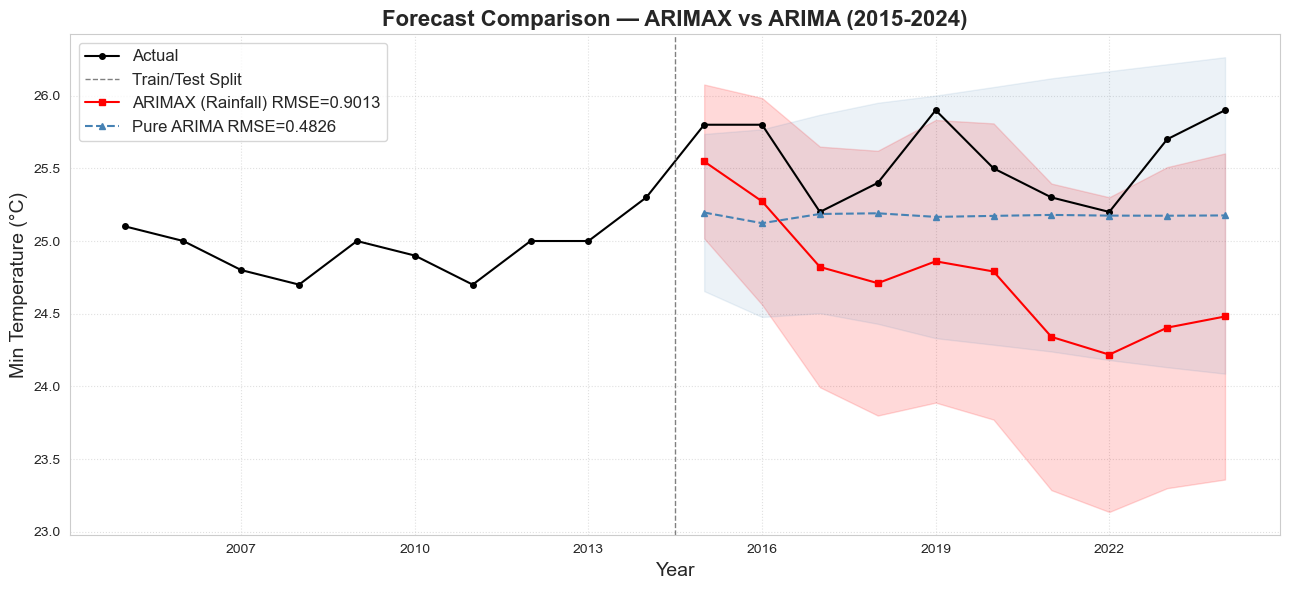

In [38]:
# 6.2 Pure ARIMA与ARIMAX预测对比图
plt.figure(figsize=(13, 6))

history_start = 2005
recent_actual = data['Temp_Min'].loc[history_start:2024]
plt.plot(recent_actual.index, recent_actual, color='black', marker='o', 
         label='Actual', linewidth=1.5, markersize=4)

plt.axvline(x=2014.5, color='gray', linestyle='--', linewidth=1, label='Train/Test Split')

fc_pred_arimax.index = yt_test.index
fc_pred.index = yt_test.index

plt.plot(fc_pred_arimax.index, fc_pred_arimax, color='red', marker='s', 
         label=f'ARIMAX (Rainfall) RMSE={rmse_arimax:.4f}', linewidth=1.5, markersize=4)
plt.fill_between(fc_pred_arimax.index, 
                 fc_ci_arimax.iloc[:, 0], fc_ci_arimax.iloc[:, 1], 
                 color='red', alpha=0.15)

plt.plot(fc_pred.index, fc_pred, color='steelblue', linestyle='--', marker='^', 
         label=f'Pure ARIMA RMSE={rmse_arima:.4f}', linewidth=1.5, markersize=4)
plt.fill_between(fc_pred.index, 
                 fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], 
                 color='steelblue', alpha=0.1)

plt.title('Forecast Comparison — ARIMAX vs ARIMA (2015-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year',fontsize=14)
plt.ylabel('Min Temperature (°C)',fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, fontsize=12)
plt.locator_params(axis='x', nbins=10)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ARIMAX_vs_ARIMA_Performance_Comparison.png')
plt.show()